### import Packages

In [29]:
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from rasterio.enums import Resampling
from rasterio.warp import reproject, calculate_default_transform

### Set the file pats

In [37]:
# ── Paths ─────────────────────────────────────────────────────
FS_PATH  = r"D:\Research\Flood Susceptibility\Data\Rasters\Pop_DFO_SAR_rasters\FS_Kosi.tif"
POP_PATH = r"C:\Users\kkhan16\OneDrive - Saint Louis University\Documents\ArcGIS\Projects\Geo_ana\pop_100.tif"

### Check raster properties

In [38]:
# ── Load WorldPop at NATIVE resolution (no resampling) ────────
with rasterio.open(POP_PATH) as pop_src:
    pop           = pop_src.read(1).astype(float)
    pop_nodata    = pop_src.nodata
    pop_transform = pop_src.transform
    pop_crs       = pop_src.crs
    pop_height    = pop_src.height
    pop_width     = pop_src.width
    print(f"WorldPop resolution : {pop_src.transform.a:.1f} x {abs(pop_src.transform.e):.1f} m")
    print(f"WorldPop shape      : {pop_height} x {pop_width}")

WorldPop resolution : 88.0 x 88.0 m
WorldPop shape      : 1838 x 1600


### Match all the rasters

In [39]:
# ── Reproject FS → WorldPop grid (downscale 30m → 100m) ───────
with rasterio.open(FS_PATH) as fs_src:
    fs_resampled = np.zeros((pop_height, pop_width), dtype=np.float32)
    reproject(
        source        = rasterio.band(fs_src, 1),
        destination   = fs_resampled,
        src_transform = fs_src.transform,
        src_crs       = fs_src.crs,
        dst_transform = pop_transform,
        dst_crs       = pop_crs,
        resampling    = Resampling.average,   # average 30m → 100m
        src_nodata    = fs_src.nodata,
        dst_nodata    = np.nan
    )

fs = fs_resampled.astype(float)

### Mask no data

In [40]:
# ── Mask nodata ───────────────────────────────────────────────
fs  = np.where((fs == -9999) | (fs <= 0), np.nan, fs)
pop = np.where(pop > 1e+30,  np.nan, pop)
pop = np.where(pop < 0,      np.nan, pop)
pop = np.where(np.isnan(fs), np.nan, pop)   # clip to study area

total_pop = np.nansum(pop)
print(f"\nCorrected Total Population : {int(total_pop):,}")
print(f"Expected range             : 13,000,000 – 17,000,000")


Corrected Total Population : 17,073,657
Expected range             : 13,000,000 – 17,000,000


### Estimate the Population

In [45]:
# ── Your quantile breaks ──────────────────────────────────────
breaks = [0.0, 0.227, 0.3686, 0.509, 0.6588, 1.0]
labels = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']
colors = ['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c']

fs_classes = np.digitize(fs, breaks[1:-1]) + 1
fs_classes = np.where(np.isnan(fs), np.nan, fs_classes)

# ── Population per class ──────────────────────────────────────
pop_by_class = {cls: np.nansum(pop[fs_classes == cls]) for cls in range(1, 6)}

# ── Results ───────────────────────────────────────────────────
rows = []
for cls, label, color in zip(range(1, 6), labels, colors):
    val = int(pop_by_class[cls])
    pct = val / total_pop * 100
    rows.append({
        'Class'     : cls,
        'Zone'      : label,
        'Range'     : f"{breaks[cls-1]}–{breaks[cls]}",
        'Population': val,
        'Percentage': round(pct, 2),
        'Color'     : color
    })

pop_df = pd.DataFrame(rows)


print(f"{'Zone':<12} {'Range':<18} {'Population':>12} {'%':>8}")
for _, r in pop_df.iterrows():
    print(f"{r['Zone']:<12} {r['Range']:<18} {r['Population']:>12,} {r['Percentage']:>7.2f}%")
print(f"{'─'*57}")

at_risk     = sum(pop_by_class[c] for c in [4, 5])
at_risk_pct = at_risk / total_pop * 100
print(f"{'At-Risk (High+Very High)':<30} {int(at_risk):>12,} {at_risk_pct:>7.2f}%")
print(f"{'Total':<30} {int(total_pop):>12,} {'100.00%':>8}")


Zone         Range                Population        %
Very Low     0.0–0.227             5,287,025   30.97%
Low          0.227–0.3686          5,395,948   31.60%
Moderate     0.3686–0.509          3,704,305   21.70%
High         0.509–0.6588          2,018,634   11.82%
Very High    0.6588–1.0              667,744    3.91%
─────────────────────────────────────────────────────────
At-Risk (High+Very High)          2,686,378   15.73%
Total                            17,073,657  100.00%


### Plot the data

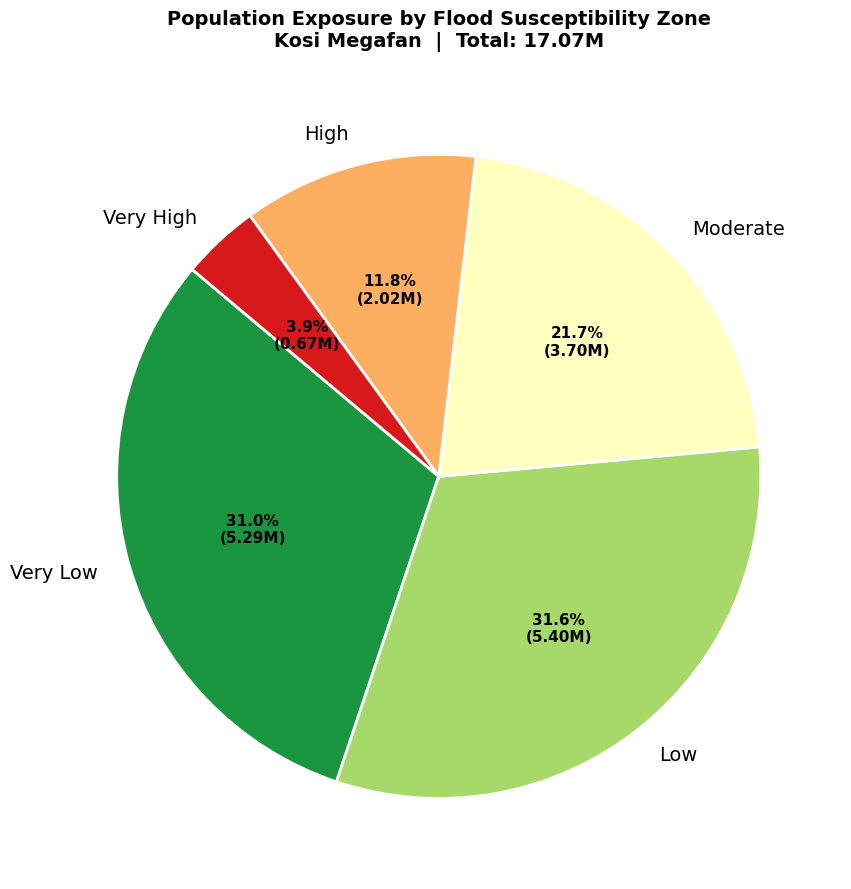

In [43]:
# ── Pie chart ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    pop_df['Population'],
    labels=pop_df['Zone'],
    colors=pop_df['Color'],
    autopct=lambda pct: f'{pct:.1f}%\n({pct/100 * total_pop / 1e6:.2f}M)',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 14}
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
ax.set_title(f'Population Exposure by Flood Susceptibility Zone\nKosi Megafan  |  Total: {total_pop/1e6:.2f}M',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(r'D:\Research\Flood Susceptibility\Data\Rasters\output\population_pie_corrected.png',
            dpi=600, bbox_inches='tight')
plt.show()


### Map the data

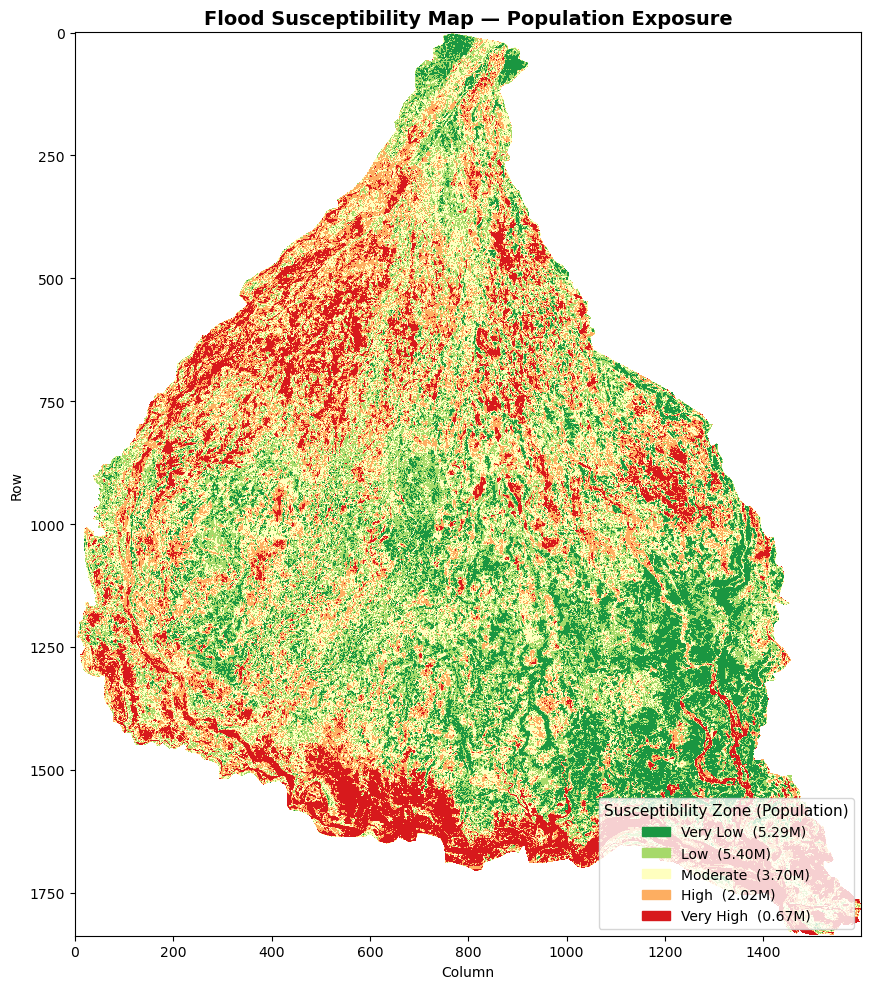

In [44]:
# ── Susceptibility map with population overlay ────────────────
fig, ax = plt.subplots(figsize=(12, 10))

cmap_zones = plt.cm.colors.ListedColormap([c['color'] for c in zone_config.values()])
im = ax.imshow(fs_classes, cmap=cmap_zones, vmin=1, vmax=5, interpolation='none')

patches = [mpatches.Patch(color=cfg['color'],
           label=f"{cfg['label']}  ({pop_df[pop_df['Class']==cls]['Population'].values[0]/1e6:.2f}M)")
           for cls, cfg in zone_config.items()]
ax.legend(handles=patches, loc='lower right', fontsize=10,
          title='Susceptibility Zone (Population)', title_fontsize=11)

ax.set_title('Flood Susceptibility Map — Population Exposure', fontsize=14, fontweight='bold')
ax.set_xlabel('Column')
ax.set_ylabel('Row')
plt.tight_layout()
plt.show()
